# Indiana Bosonic Code - DMANH

In [1]:
from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()

#from Experiment import Experiment
import numpy as np
import csv
from datetime import datetime, date, time, timezone
from pytz import timezone
from collections import OrderedDict
import pytz
from scipy.special import jn_zeros
import math
import matplotlib.pyplot as plt
import pickle as pkl
from jaqalpaq.parser import parse_jaqal_string
from pprint import pprint
import ast
from pathlib import Path
from textwrap import dedent


def timestamp_generate():
    mountain = timezone('US/Mountain')
    timestamp_utc = datetime.utcnow()
    timestamp_local = timestamp_utc.astimezone(mountain)
    return(timestamp_utc, timestamp_local)

def int_to_base(n, b):
    if n == 0:
        return "0"
    digits = []
    is_negative = n < 0
    n = abs(n)
    while n:
        digits.append(int(n % b))
        n //= b
    if is_negative:
        digits.append("-")
    return ''.join(str(x) if x < 10 else chr(55 + x) for x in reversed(digits))



In [2]:
nq = 2
repeats = 500
im_beta_list = np.linspace(-0.4, 0.4, 5).tolist()

# Keep the readout beta sweep and SQR/Rz angle explicit in this notebook.
# The compiler export supplies the per-step SDF displacement angles.
Z_ANGLE = -0.8

working_dir = Path.cwd()
try:
    compiled_angles = np.load(working_dir / "Indiana_DMANH_bosonic_data.npy")  # rows: first xSDF re, first xSDF im, phi - JBG
    file_path = working_dir
except FileNotFoundError:
    recursive_dir = working_dir
    for ii in range(5):
        temp_dir = recursive_dir.parent
        recursive_dir = temp_dir
    file_path = recursive_dir
    compiled_angles = np.load(file_path / "Indiana_DMANH_bosonic_data.npy")  # rows: first xSDF re, first xSDF im, phi - JBG
with open(file_path / "Indiana_DMANH_bosonic.config", "r") as f:
    do_first_half = bool(f.read())

if compiled_angles.shape[0] != 3:
    raise ValueError(f"expected angles.npy with shape (3, steps), got {compiled_angles.shape}")

angle = -compiled_angles[:2].T
num_subcircuits = len(angle) + 1  # subcircuits with 0, 1, ..., N Trotter steps
subcircuit_steps = np.arange(num_subcircuits)

print(angle.shape)
print(type(angle))
print(angle.dtype)
print(angle)


(49, 2)
<class 'numpy.ndarray'>
float64
[[ 0.18512012  0.        ]
 [ 0.18128961  0.0374638 ]
 [ 0.1699566   0.0733772 ]
 [ 0.15159009  0.10625396]
 [ 0.12695018  0.13473349]
 [ 0.09705654  0.1576372 ]
 [ 0.06314632  0.17401725]
 [ 0.02662284  0.18319575]
 [-0.0110024   0.18479288]
 [-0.04817231  0.17874252]
 [-0.08334866  0.16529507]
 [-0.11507571  0.14500704]
 [-0.14204045  0.11871803]
 [-0.16312698  0.08751599]
 [-0.17746266  0.05269218]
 [-0.18445421  0.01568775]
 [-0.18381229 -0.0219659 ]
 [-0.17556348 -0.05871051]
 [-0.16004914 -0.09302544]
 [-0.13791131 -0.12349061]
 [-0.11006616 -0.14884522]
 [-0.07766602 -0.16804002]
 [-0.04205174 -0.18028064]
 [-0.0046972  -0.18506052]
 [ 0.03285174 -0.18218184]
 [ 0.06904114 -0.17176374]
 [ 0.10237333 -0.15423735]
 [ 0.1314689  -0.130328  ]
 [ 0.15512376 -0.10102514]
 [ 0.17235896 -0.06754146]
 [ 0.18246125 -0.03126263]
 [ 0.18501255  0.00630997]
 [ 0.17990728  0.04362143]
 [ 0.16735672  0.07912767]
 [ 0.14788026  0.11135928]
 [ 0.12228391  

In [3]:
override_dict = {"__repeats__": repeats,
                 "phi": Z_ANGLE,
                 "imBeta": im_beta_list,}

In [4]:
class JaqalGenerator:
    header = dedent("""
        from Calibration_PulseDefinitions.QubitBosonPulses usepulses *
        let phi -0.8
        let reBeta -0.2
        let imBeta 0

        register q[2]\n
    """).lstrip()

    subcircuit_header = dedent("""
        // ******************* //
        // Subcircuit with {subcirc_idx} Trotter steps
        prepare_all
        // Wavepacket preparation: |down>|0> -> |down>|x=-x_min> using zCD.
        zSDF q[0] 0.89021208217480396 0\n
    """).lstrip()

    trotter_step = dedent("""
        // Evolution step {time_step} 
        xSDF q[0] {reBeta} {imBeta}
        Rz q[0] phi
        xSDF q[0] {m_reBeta} {m_imBeta}
        xSDF q[0] {m_reBeta} {m_imBeta}
        Rz q[0] phi
        xSDF q[0] {reBeta} {imBeta}
    """).lstrip()
    
    subcircuit_footer = dedent("""
        // Characteristic-function readout.
        R q[1] 0 1.5707963267948966
        xSDF q[1] reBeta imBeta
        measure_all
        // ******************* //\n\n
    """).lstrip()

    @classmethod
    def generate(self, angle_data: np.ndarray) -> str:
        jaqal_string = self.header
        for ii in range(num_subcircuits):
            jaqal_string += self._gen_subcircuit(ii, angle_data)
        return jaqal_string
    
    @classmethod
    def _gen_subcircuit(self, trotter_steps: int, angle_data: np.ndarray) -> str:
        subcircuit = self.subcircuit_header.format(subcirc_idx=trotter_steps)
        for ii in range(trotter_steps):
            subcircuit += self.trotter_step.format(time_step=ii + 1,
                                                   reBeta=angle_data[ii, 0],
                                                   imBeta=angle_data[ii, 1],
                                                   m_reBeta=-angle_data[ii, 0],
                                                   m_imBeta=-angle_data[ii, 1],
                                                   phi=Z_ANGLE)
        subcircuit += self.subcircuit_footer
        return subcircuit



In [5]:
# The for loop was removed because batching has been moved to overrides (also some of the names have changed, sorry).

jaqal_string = JaqalGenerator.generate(angle_data=angle)

print(jaqal_string)

from Calibration_PulseDefinitions.QubitBosonPulses usepulses *
let phi -0.8
let reBeta -0.2
let imBeta 0

register q[2]

// ******************* //
// Subcircuit with 0 Trotter steps
prepare_all
// Wavepacket preparation: |down>|0> -> |down>|x=-x_min> using zCD.
zSDF q[0] 0.89021208217480396 0

// Characteristic-function readout.
R q[1] 0 1.5707963267948966
xSDF q[1] reBeta imBeta
measure_all
// ******************* //


// ******************* //
// Subcircuit with 1 Trotter steps
prepare_all
// Wavepacket preparation: |down>|0> -> |down>|x=-x_min> using zCD.
zSDF q[0] 0.89021208217480396 0

// Evolution step 1 
xSDF q[0] 0.18512012242326523 0.0
Rz q[0] phi
xSDF q[0] -0.18512012242326523 -0.0
xSDF q[0] -0.18512012242326523 -0.0
Rz q[0] phi
xSDF q[0] 0.18512012242326523 0.0
// Characteristic-function readout.
R q[1] 0 1.5707963267948966
xSDF q[1] reBeta imBeta
measure_all
// ******************* //


// ******************* //
// Subcircuit with 2 Trotter steps
prepare_all
// Wavepacket pre

In [6]:
results = run.run_jaqal_string(jaqal_string, overrides = override_dict)

# print(results)

In [7]:
def exp_z(prob): #Postselect the results on the 
    """Expectation value of Z"""
    #probe qubit's state probabilities
    if prob[0] + prob[2] == 0:
        state0 = 0
        state1 = 0
    else:
        state0 = prob[0]/(prob[0]+prob[2])
        state1 = prob[2]/(prob[0]+prob[2])
    
    return state0 - state1

In [8]:
#Extract the data from the results object
#This extracts the axis data

imMeas = np.empty((len(im_beta_list), num_subcircuits, 2 ** nq))
expZ_imMeas = np.empty((len(im_beta_list), num_subcircuits))

print(len(results.by_subbatch[0].by_subcircuit[0].probability_by_int[:,0]))

for ii in range(len(im_beta_list)):
    for jj in range(num_subcircuits):
        imMeas[ii, jj, :] = results.by_subbatch[ii].by_subcircuit[jj].probability_by_int[:,0]
        expZ_imMeas[ii, jj] = exp_z(imMeas[ii, jj])
print(imMeas[0, 0])
print(expZ_imMeas)
np.save('expZ_imMeas',expZ_imMeas) 

#If you want to have the outputs available in a text format, the save functions below are useful. 
# #Save all probabilities
# np.save('prob_imMeas',imMeas)

# #Save beta ranges
# np.save('ImBetas',im_values)


4
[0.372 0.    0.622 0.006]
[[-0.25150905 -0.32589286 -0.2969697  -0.24463519 -0.408      -0.45238095
  -0.28767123 -0.2        -0.22807018 -0.18181818 -0.27338129 -0.2555205
  -0.13915858 -0.27946128 -0.27272727 -0.2        -0.1957672  -0.07575758
  -0.03875969 -0.11111111 -0.2688172  -0.07623318 -0.13913043 -0.14396887
  -0.01176471  0.01459854 -0.10121457 -0.07296137 -0.07936508 -0.05813953
  -0.11494253  0.01796407 -0.12903226 -0.1010101   0.07692308 -0.03968254
  -0.01901141  0.01204819  0.03862661  0.04464286  0.01382488 -0.01086957
   0.04081633  0.1122449  -0.02463054  0.07177033 -0.04807692  0.11392405
   0.02586207  0.05263158]
 [-0.10707071 -0.19376392 -0.1661442  -0.10377358 -0.14285714 -0.08
  -0.04444444 -0.06542056 -0.10429448 -0.12605042 -0.10067114 -0.07165109
  -0.21341463 -0.17647059 -0.11940299 -0.05777778 -0.16384181 -0.07317073
  -0.19402985 -0.04402516 -0.09452736 -0.04081633 -0.11304348 -0.03100775
  -0.02459016 -0.06995885 -0.17647059 -0.09322034 -0.09268293 -0

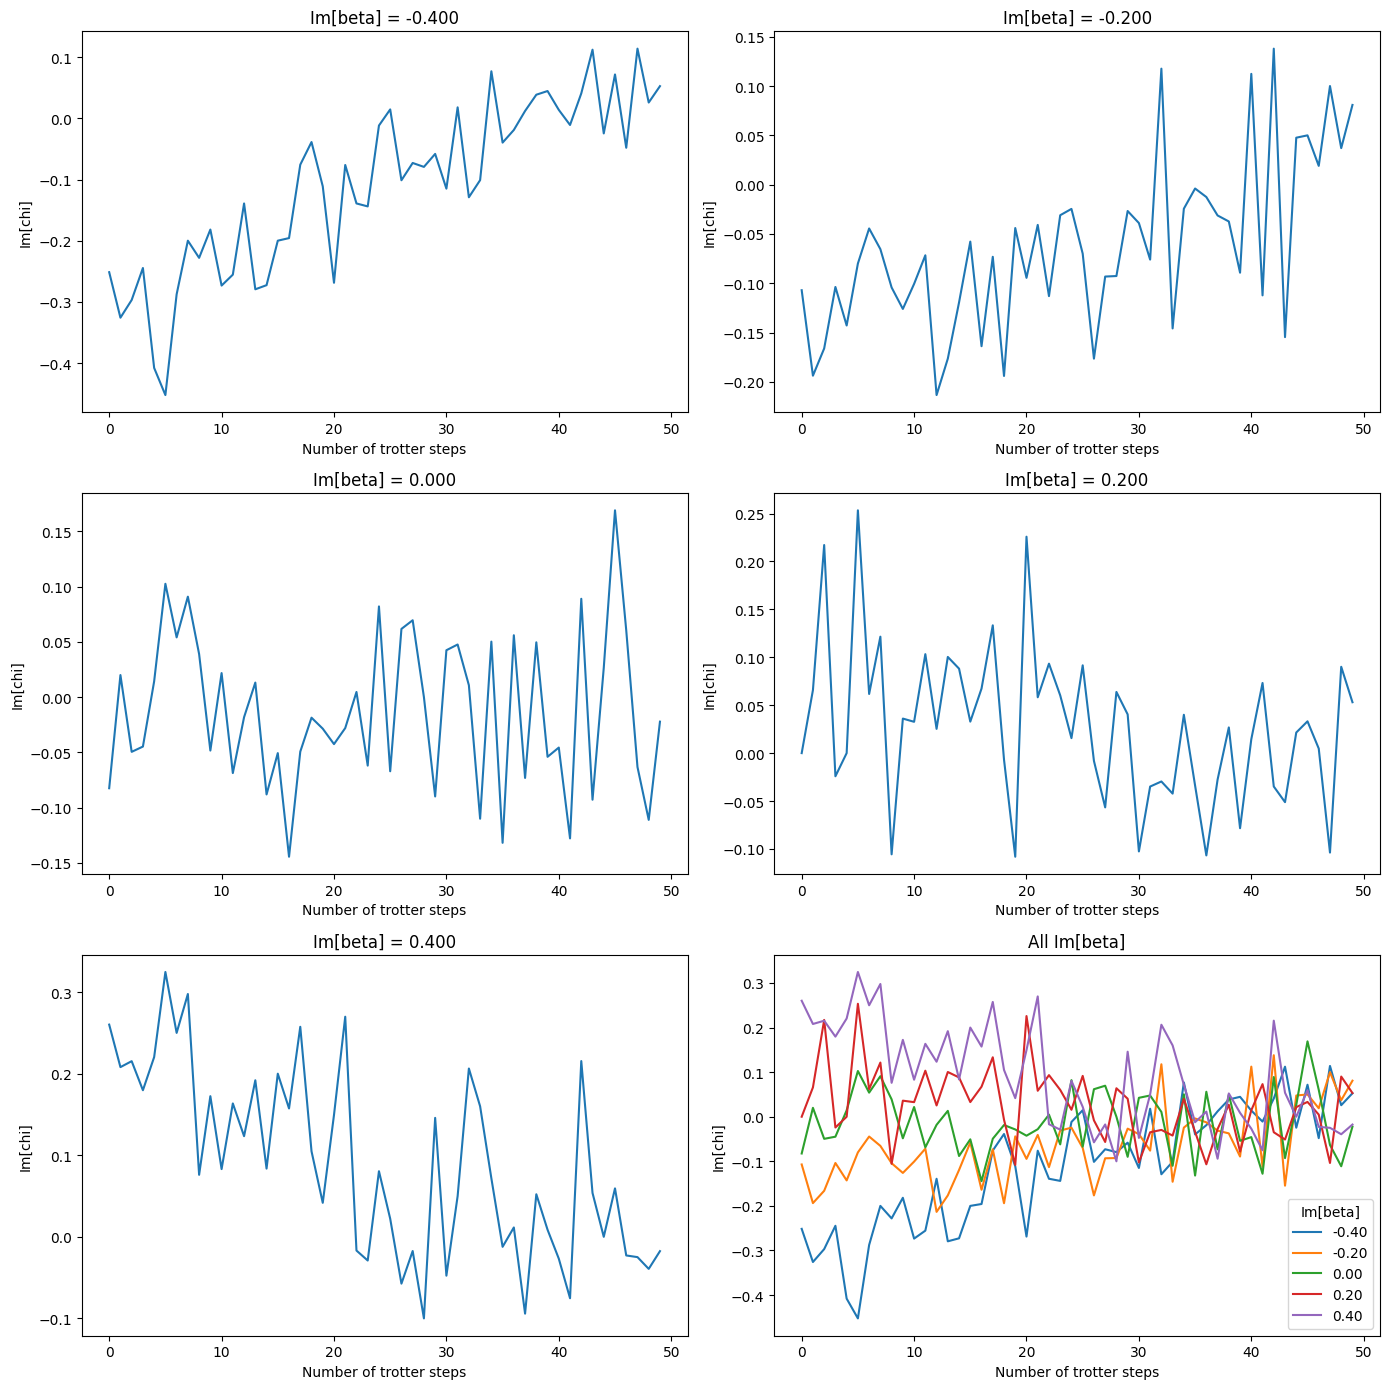

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(14, 14))
fig.subplots_adjust(hspace=.15, wspace=.1)        
axes = axs.ravel()

for ii, beta in enumerate(im_beta_list):
    axes[ii].plot(subcircuit_steps, expZ_imMeas[ii, :], label=f"{beta:.2f}")
    axes[ii].set_title(f"Im[beta] = {beta:.3f}")
    axes[ii].set_xlabel("Number of trotter steps")
    axes[ii].set_ylabel("Im[chi]")
fig.tight_layout()

lastplot = len(im_beta_list)

for  ii, beta in enumerate(im_beta_list):
    axes[lastplot].plot(subcircuit_steps, expZ_imMeas[ii, :], label=f"{beta:.2f}")
axes[lastplot].set_title('All Im[beta]')
axes[lastplot].set_xlabel("Number of trotter steps")
axes[lastplot].set_ylabel("Im[chi]")
axes[lastplot].legend(title="Im[beta]")
fig.tight_layout()
